# 04 — Per-mode limits: the three sensor modes on one plane

**Paper element.** None directly. This is the per-mode cross-check behind the
single-mode Supplementary Limit Figures, which print one mode at a time.
[`01_limit_contour.ipynb`](01_limit_contour.ipynb) analyses one mode in depth;
this notebook reads the same stored surfaces for all three at once, so the
modes can be compared without flipping between figures.

**Which cube.** The released file named in `RELEASE_FILE` below: the
$f_\mathrm{DM} = 1$ plane with atmospheric attenuation applied, the convention
the Letter quotes its $\alpha_n$ limits at. Nothing here is recomputed — every
contour is a level set of that file's stored extremeness surface. The file
carries that one dark matter fraction and no other, so `f_dm=1.0` is passed on
every read rather than left to the loader's fallback, which is the build-side
baseline and is not on this file's axis at all.

**Mass window.** The analysis window starts at $q_\mathrm{min}$ = 1 TeV$/c$,
which puts a hard kinematic wall at
$q_\mathrm{min}/v_\mathrm{esc} = 5.51\times10^{5}$ GeV: below it the halo cannot
place a single countable kick, at any coupling, through any mediator
(the anatomy is in
[`10_left_edge_anatomy.ipynb`](10_left_edge_anatomy.ipynb)). The
impact-parameter integral is uncapped, so nothing in the stored surfaces closes
the massless contour on the right; the right-hand edge drawn here is the halo
flux cut $m_\mathrm{cut}$, read from the file's attributes, which assumes three
expected transits within 10 cm of the sensor during the exposure. That
assumption is a choice rather than a measurement, so it is restated on every
figure that draws the cut, and the cut is drawn as a dashed brown line rather
than baked into the surfaces (see
[`11_right_edge_flux_cut.ipynb`](11_right_edge_flux_cut.ipynb)).

**Encoding.** **hue = mode** (1 blue / 2 orange / 3 purple): one hue per mode,
the same hue in every figure that mode appears in. Green is deliberately not in
the set, so no red guide line can end up adjacent to a green curve.
**shade = mediator range** (long range dark → short range light) and
**line style = range** (massless solid; the finite ranges per the matplotlib
linestyle gallery). Set `PLOT_MODES` below to `(1,)`, `(2, 3)`, … to draw a
subset of the modes; the figure filenames follow the selection.

**Why the modes differ at all.** The three sensors watch the same halo, so the
spread between their contours is candidate count and detection efficiency and
nothing else. Modes 1 and 2 both reach half efficiency near the bottom of the
analysis window, mode 2 the softer of the two; mode 3 turns on several TeV
above the window edge, so its softest in-window candidate sits far out on the
toe of its efficiency curve and it pays by far the largest efficiency price.
Which mode ends up with the deepest coupling floor is the outcome of that
balance against the candidate counts, and it has changed as the efficiency
treatment changed, so it is not asserted here in prose: the summary cell below
reads the ordering off the cube.

In [1]:
%matplotlib inline
import colorsys
import os as _os
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from luhdm import config, units
from luhdm import release

# ---- the released file this notebook reads (one line to change on a reissue)
# File A of the released pair: f_DM = 1 with atmospheric attenuation, the plane
# the Letter quotes its alpha_n limits on. Its lambda axis carries the three
# physics ranges, a long-range convergence slice and the massless sentinel.
RELEASE_FILE = "../release/luhdm_datarelease_v7_A_f1_atm.h5"

rel = release.open_release(RELEASE_FILE)

# ---- which modes to draw (edit me: (1,), (2, 3), (1, 2, 3), ...) ----
PLOT_MODES = (1, 2, 3)
ALL_MODES = (1, 2, 3)

CONF = 0.95
# This file carries one dark matter fraction, so it is threaded through every
# rel.* call below rather than left to the loader default -- that default is the
# build-side baseline 0.1, which is not on this file's axis and raises.
F_DM = 1.0
F_DM_TXT = r"$f_\mathrm{DM}$ = 1"
M_PLANCK = 1.22e19                     # GeV; the top of the mass axis

# the scheme this notebook assumes, checked against the file rather than
# trusted: the 1 TeV analysis window and an uncapped impact-parameter integral
assert float(rel.attrs["q_thresh_gev"]) == float(config.Q_THRESH), \
    "this cube was built for a different analysis window"
assert rel.b_constrained_max is None, \
    "this cube caps the impact-parameter integral; this notebook needs the uncapped release"

M_WALL = config.Q_THRESH / config.VESC   # kinematic wall, GeV: no lighter mass
                                         # delivers a threshold kick at any coupling
# the halo flux cut that closes every region on the right. Stored as an
# attribute rather than baked into the surfaces, because the number of transits
# it demands is a choice, not a measurement.
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])
B_CAP = float(rel.attrs["m_cut_b_cap_m"])
CUT_TXT = (f"assumes {N_REQ:g} expected transits\n"
           f"within {B_CAP * 100:.0f} cm during the exposure")

# Mode hue: Okabe-Ito blue / orange / reddish-purple, written out here rather
# than imported from the paper style module, whose import switches matplotlib to
# Agg and would kill the inline backend. One hue per mode, the same one in every
# figure the mode appears in; green is deliberately not in the set, so no red
# guide line elsewhere can end up adjacent to a green curve.
BASE = {1: "#0072B2", 2: "#E69F00", 3: "#CC79A7"}

# The released mediator ranges, ordered by physical range (long -> short) with
# massless first. Shade runs dark (long range) -> light (short range); line
# style is per range. The cube also carries a long-range convergence slice,
# which is a numerical check rather than a physics case and is not drawn.
RANGES = ["massless", "2mm", "200um", "20um"]
LABEL = {"massless": "massless", "2mm": "2 mm", "200um": "200 µm",
         "20um": "20 µm"}
# line styles from https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
STYLE = {
    "massless": "solid",
    "2mm":   (0, (3, 5, 1, 5)),      # dashdotted
    "200um": (0, (5, 5)),            # dashed
    "20um":  (0, (3, 1, 1, 1)),      # densely dashdotted
}
FRAC = {tag: i / (len(RANGES) - 1) for i, tag in enumerate(RANGES)}


def shade(mode, tag):
    """Shade of the mode's base hue for one range (dark=long, light=short)."""
    r, g, b = mcolors.to_rgb(BASE[mode])
    h, _, s = colorsys.rgb_to_hls(r, g, b)
    return colorsys.hls_to_rgb(h, 0.25 + 0.42 * FRAC[tag], s)


def load(mode, tag):
    """This mode's (mass, alpha_n) extremeness surface for one range."""
    return dict(ms=rel.axes.mass_gev,
                alphas_n=rel.axes.alpha_n,
                extremeness=rel.mass_plane("extremeness", mode, tag,
                                           f_dm=F_DM))


def _halo_text(txt):
    txt.set_path_effects([pe.Stroke(linewidth=2.2, foreground="w"), pe.Normal()])
    return txt


def mark_wall(ax, y=0.015):
    # the kinematic wall: nothing to its left is excludable at any coupling
    ax.axvline(M_WALL, color="#444444", lw=1.4, ls=(0, (4, 2, 1, 2)), zorder=1)
    _halo_text(ax.text(M_WALL, y, r" $m_{\mathrm{wall}}$", color="#444444",
                       fontsize=9, ha="left", va="bottom", rotation=90,
                       zorder=1.5,   # under the contours: no halo notches them
                       transform=ax.get_xaxis_transform()))


def mark_m_cut(ax, y=0.985):
    # the flux cut: right-hand edge of every region drawn here. Everything to
    # its right is a statement about a flux the halo does not deliver.
    ax.axvline(M_CUT, color="#8c564b", lw=1.3, ls=(0, (6, 3)), zorder=1)
    _halo_text(ax.text(M_CUT, y, r"$m_{\mathrm{cut}}$ ", color="#8c564b",
                       fontsize=9, ha="right", va="top", rotation=90,
                       zorder=1.5, transform=ax.get_xaxis_transform()))


def mark_planck_mass(ax, m_pl=M_PLANCK, y=0.985):
    # the mass grid stops at the Planck mass: mark that endpoint (label inside)
    ax.axvline(m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    _halo_text(ax.text(m_pl, y, r"$m_{\mathrm{Pl}}$", color="#555555",
                       fontsize=9, ha="right", va="top", rotation=90,
                       zorder=1.5, transform=ax.get_xaxis_transform()))


G_PER_GEV = 1.78266192e-24     # 1 GeV/c^2 in grams


def add_gram_axis(ax, m_lo, m_hi):
    """Top axis in grams, labelled by SI prefix."""
    sec = ax.secondary_xaxis(
        "top", functions=(lambda x: x * G_PER_GEV, lambda g: g / G_PER_GEV))
    sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
    keep = [(t, l) for t, l in
            zip([1e-18, 1e-15, 1e-12, 1e-9, 1e-6],
                ["1 ag", "1 fg", "1 pg", "1 ng", "1 µg"])
            if m_lo * G_PER_GEV <= t <= m_hi * G_PER_GEV]
    sec.set_xticks([t for t, _ in keep])
    sec.set_xticklabels([l for _, l in keep])
    sec.xaxis.set_minor_locator(plt.NullLocator())
    return sec


for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)


def save_figure(fig, name, stamp=None, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix,
    # stamped with the data-release version that produced it so a figure always
    # names its cube
    fig.text(0.995, 0.004,
             f"POLONAISE UHDM data release {stamp or rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


XMAX_MASS = 3e19      # one partial decade past m_Pl, so its marker line falls
XMIN_MASS = 2.5e5     # inside the frame; and a little room left of the wall

print(f"{rel}")
print(f"q_min = {config.Q_THRESH:.0f} GeV   N_n = {config.N_NEUTRONS:.2e}   "
      f"R_eff = {config.R_EFF * 1e6:.0f} um   f_DM = {F_DM:g} "
      f"(file axis {rel.f_dm_values})")
print(f"mass window: kinematic wall {M_WALL:.3g} GeV .. flux cut {M_CUT:.3g} "
      f"GeV ({N_REQ:g} transits within {B_CAP * 100:.0f} cm -- an assumption, "
      f"see release/README.md section 5.4)")

<Release ../release/luhdm_datarelease_v7_A_f1_atm.h5 (v7.0-quick-night-m0p356mg-q1TeV-nocap)>
q_min = 1000 GeV   N_n = 1.07e+20   R_eff = 260 um   f_DM = 1 (file axis [1.0])
mass window: kinematic wall 5.51e+05 GeV .. flux cut 6.11e+14 GeV (3 transits within 10 cm -- an assumption, see release/README.md section 5.4)


## What the cube carries

Before any figure: how much of each (mode, range) surface is excluded, and
whether any cell failed. The excluded fraction is the share of the whole
(mass, coupling) grid above the 95% CL level, counted over the entire grid
rather than over the physical mass window, so it is a completeness diagnostic
and not a physics number. The `status` flag records how each cell was obtained,
and only code 1 is a failure — the cell raised, and its extremeness is stored as
`NaN`. The other non-zero codes are deterministic shortcuts, cells where the
answer is known without running the Monte Carlo, and they are the majority of
any cube. The bracket therefore counts failures, not shortcuts.

In [2]:
N_CELLS = rel.axes.alpha_n.size * rel.axes.mass_gev.size
print(f"{'range':>9} | " + "  ".join(f"mode {n}" for n in ALL_MODES)
      + "     (excluded fraction of the grid; [undefined cells of "
      + f"{len(ALL_MODES) * N_CELLS}])")
print("-" * 76)
for tag in RANGES:
    cells, bad = [], 0
    for n in ALL_MODES:
        d = load(n, tag)
        cells.append(f" {(d['extremeness'] >= CONF).mean():.3f} ")
        bad += int((rel.mass_plane("status", mode=n, lam=tag, f_dm=F_DM) == 1).sum())
    print(f"{LABEL[tag]:>9} | " + " ".join(cells) + f"   [{bad}]")

    range | mode 1  mode 2  mode 3     (excluded fraction of the grid; [undefined cells of 15708])
----------------------------------------------------------------------------
 massless |  0.490   0.468   0.431    [0]
     2 mm |  0.250   0.244   0.227    [3]
   200 µm |  0.160   0.157   0.138    [0]
    20 µm |  0.067   0.064   0.044    [75]


## The three modes on one plane, massless mediator

The reference view: each mode's 95% CL excluded region for a massless mediator
($\lambda \to \infty$), all on the same axes, with atmospheric attenuation
applied. One range means there is no shade to read here, so each contour is
drawn in its mode's own hue.

The region is bounded on the left by the kinematic wall, below by the statistics
floor, above by the atmospheric ceiling, and on the right by the halo flux cut
$m_\mathrm{cut}$ — the dashed brown line, which is drawn rather than applied, and
which assumes three expected transits within 10 cm during the exposure. Contours
continue past it because the stored surfaces do; they should not be read as
limits there. The four edges are taken apart in
[`03_understanding.ipynb`](03_understanding.ipynb),
[`10_left_edge_anatomy.ipynb`](10_left_edge_anatomy.ipynb) and
[`11_right_edge_flux_cut.ipynb`](11_right_edge_flux_cut.ipynb).

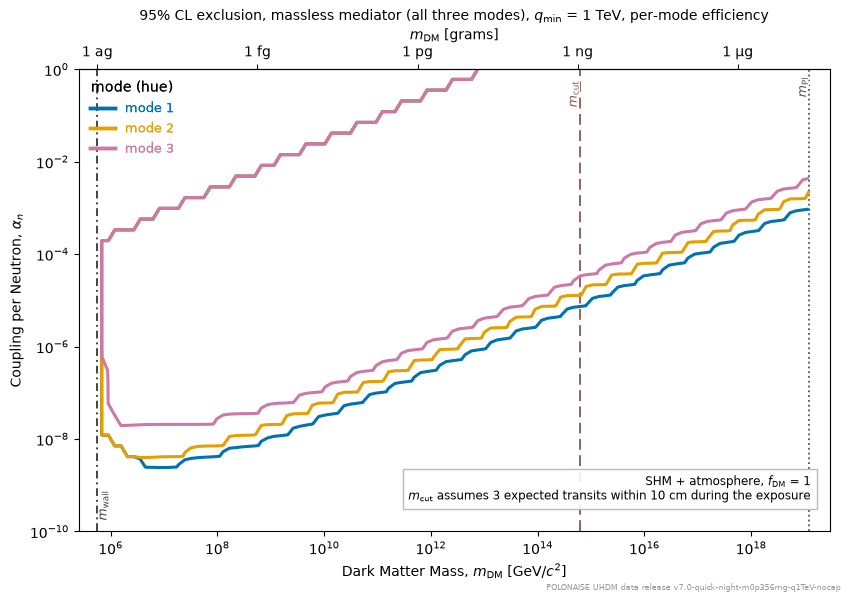

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 6))
for mode in PLOT_MODES:
    d = load(mode, "massless")
    if not (d["extremeness"] >= CONF).any():
        continue
    ax.contour(d["ms"], d["alphas_n"], d["extremeness"], levels=[CONF],
               colors=[BASE[mode]], linestyles=[STYLE["massless"]],
               linewidths=2.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(XMIN_MASS, XMAX_MASS)
ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_wall(ax)
mark_m_cut(ax)
mark_planck_mass(ax, rel.axes.mass_gev[-1])
add_gram_axis(ax, XMIN_MASS, XMAX_MASS)
ttl = ("mode " + "/".join(map(str, PLOT_MODES)) if len(PLOT_MODES) < 3
       else "all three modes")
ax.set_title(f"95% CL exclusion, massless mediator ({ttl}), "
             r"$q_{\rm min}$ = 1 TeV, per-mode efficiency", fontsize=10)

# The mode key is written straight onto the plot -- frameless, in the empty
# upper-left, each entry in that mode's own colour -- so the hue is read off the
# words themselves and not off a small swatch.
leg = ax.legend(handles=[Line2D([], [], color=BASE[m], lw=2.5, label=f"mode {m}")
                         for m in PLOT_MODES],
                loc="upper left", frameon=False, fontsize=9, title="mode (hue)")
for _t, _m in zip(leg.get_texts(), PLOT_MODES):
    _t.set_color(BASE[_m])
ax.add_artist(leg)

# the flux cut is an assumption, so it says so wherever it is drawn
ax.text(0.975, 0.06, f"SHM + atmosphere, {F_DM_TXT}\n"
        + r"$m_{\mathrm{cut}}$ " + CUT_TXT.replace("\n", " "),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
fig.tight_layout()
save_figure(fig, "04_exclusion_modes" + "".join(map(str, PLOT_MODES)))
plt.show()

## Per-mode summary: candidates, efficiency, and where each mode floors out

Three numbers separate the modes, and the cell below prints all three straight
from the cube: how many of a mode's candidates fall inside the analysis window,
where its efficiency turns on relative to the window edge, and the lowest
coupling it excludes together with the mass at which it first gets there.

The last of those is the mode ordering. The cell reads it off the cube and names
whichever mode reaches the deepest floor, rather than repeating a number in
prose — the ordering is a close race between the candidate counts and the
efficiency penalties, and the efficiency treatment can re-deal it.

Floors are quoted **inside the mass window only**: below the kinematic wall
nothing is excluded, and to the right of the flux cut the surfaces describe a
flux the halo does not deliver, so only the cells between the two are counted.

In [4]:
MS, AL = rel.axes.mass_gev, rel.axes.alpha_n
WINDOW = (MS >= M_WALL) & (MS <= M_CUT)

print(f"analysis window q_min = {config.Q_THRESH:.0f} GeV;  mass window "
      f"{M_WALL:.3g} .. {M_CUT:.3g} GeV")
print(f"  (the upper end assumes {N_REQ:g} expected transits within "
      f"{B_CAP * 100:.0f} cm during the exposure -- an assumption)\n")

print(f"{'mode':>5} {'cands':>6} {'in window':>10} {'softest in [GeV]':>17} "
      f"{'eff. there':>11} {'50% eff. at':>12} {'eff. at q_min':>14}")
for m in ALL_MODES:
    ev = np.sort(rel.events(m))
    q, e = rel.efficiency_curve(m)
    inw = ev[ev >= config.Q_THRESH]
    print(f"{m:>5} {ev.size:>6} {inw.size:>10} {inw.min():>17.0f} "
          f"{float(np.interp(inw.min(), q, e)):>11.2e} "
          f"{float(np.interp(0.5, e, q)):>12.0f} "
          f"{float(np.interp(config.Q_THRESH, q, e)):>14.3f}")

print("\nlowest excluded coupling inside the mass window, per mode and range:")
floors = {}
for tag in RANGES:
    for m in ALL_MODES:
        excl = (rel.mass_plane("extremeness", m, tag, f_dm=F_DM) >= CONF) \
            & WINDOW[None, :]
        if not excl.any():
            print(f"  {LABEL[tag]:>9}  mode {m}: nothing excluded")
            continue
        ia = int(np.where(excl.any(axis=1))[0][0])
        m_floor = MS[excl[ia]]
        m_all = MS[excl.any(axis=0)]
        floors[(tag, m)] = float(AL[ia])
        print(f"  {LABEL[tag]:>9}  mode {m}: floor alpha_n = {AL[ia]:.2e} "
              f"(first reached at m = {m_floor.min():.1e} GeV); "
              f"excluded masses {m_all.min():.1e} .. {m_all.max():.1e} GeV")

deep = {m: floors[("massless", m)] for m in ALL_MODES if ("massless", m) in floors}
if deep:
    lo = min(deep.values())
    best = [m for m, v in deep.items() if v == lo]
    tie = "" if len(best) == 1 else "  (a tie on the coupling grid)"
    print(f"\ndeepest floor on the massless plane: alpha_n = {lo:.2e}, set by "
          f"mode {' and '.join(map(str, best))}{tie}")
    print("  per mode: " + ",  ".join(f"mode {m}: {v:.2e}"
                                      for m, v in sorted(deep.items())))

analysis window q_min = 1000 GeV;  mass window 5.51e+05 .. 6.11e+14 GeV
  (the upper end assumes 3 expected transits within 10 cm during the exposure -- an assumption)

 mode  cands  in window  softest in [GeV]  eff. there  50% eff. at  eff. at q_min
    1      8          8              1521    9.87e-01          964          0.589
    2     26         24              1015    8.71e-01          751          0.864
    3    126        126              1569    1.70e-02         4403          0.000

lowest excluded coupling inside the mass window, per mode and range:
   massless  mode 1: floor alpha_n = 2.49e-09 (first reached at m = 4.7e+06 GeV); excluded masses 6.8e+05 .. 4.7e+14 GeV
   massless  mode 2: floor alpha_n = 4.25e-09 (first reached at m = 2.1e+06 GeV); excluded masses 6.8e+05 .. 4.7e+14 GeV
   massless  mode 3: floor alpha_n = 2.12e-08 (first reached at m = 1.6e+06 GeV); excluded masses 6.8e+05 .. 4.7e+14 GeV
       2 mm  mode 1: floor alpha_n = 2.49e-09 (first reached at m = 4.

## The finite mediator ranges

The same three modes at each released finite range, now with the full encoding:
hue is still the mode, and shade plus line style pick out the range (dark and
long-dashed = 2 mm, through to light and densely dash-dotted = 20 µm). The
massless contours of the previous figure are the $\lambda \to \infty$ limit of
this family and are left off so the finite ranges stay legible.

Two patterns run across the family, and they run the same way for all three
modes. Ranges in the Coulomb regime share a common coupling floor, while shorter
ranges pay the momentum-cap penalty and floor out higher — 20 µm sits visibly
above 200 µm. And the high-mass endpoints ladder with $\lambda$: the reach
saturates as $\sigma \sim \lambda^2$ while the number density falls as $1/m$, so
each decade of range buys roughly two decades of mass, and every finite-range
island closes on its own well left of the flux cut.

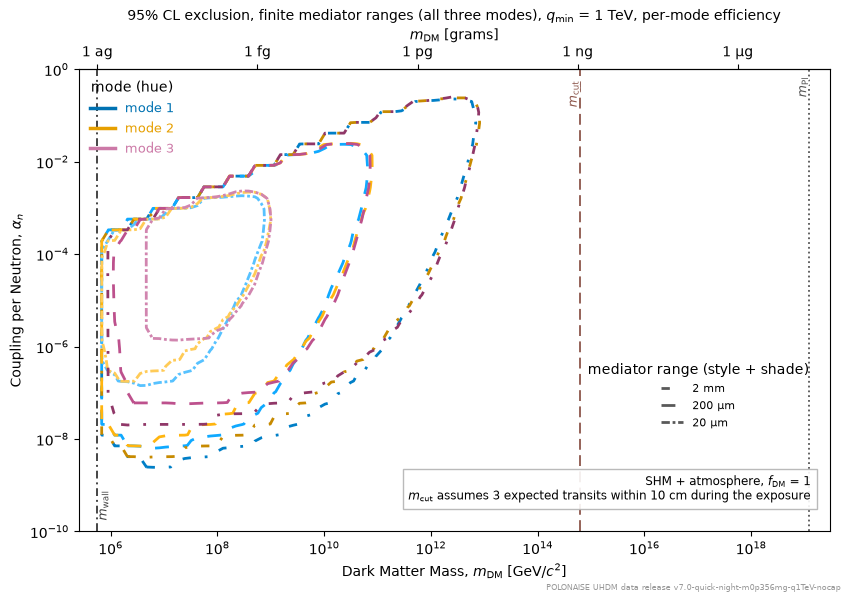

In [5]:
FINITE = [t for t in RANGES if t != "massless"]

fig, ax = plt.subplots(figsize=(8.5, 6))
drawn = []
for mode in PLOT_MODES:
    for tag in FINITE:
        d = load(mode, tag)
        if not (d["extremeness"] >= CONF).any():
            continue
        if tag not in drawn:
            drawn.append(tag)
        ax.contour(d["ms"], d["alphas_n"], d["extremeness"], levels=[CONF],
                   colors=[shade(mode, tag)], linestyles=[STYLE[tag]],
                   linewidths=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(XMIN_MASS, XMAX_MASS)
ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_wall(ax)
mark_m_cut(ax)
mark_planck_mass(ax, rel.axes.mass_gev[-1])
add_gram_axis(ax, XMIN_MASS, XMAX_MASS)
ttl = ("mode " + "/".join(map(str, PLOT_MODES)) if len(PLOT_MODES) < 3
       else "all three modes")
ax.set_title(f"95% CL exclusion, finite mediator ranges ({ttl}), "
             r"$q_{\rm min}$ = 1 TeV, per-mode efficiency", fontsize=10)

leg = ax.legend(handles=[Line2D([], [], color=BASE[m], lw=2.5, label=f"mode {m}")
                         for m in PLOT_MODES],
                loc="upper left", frameon=False, fontsize=9, title="mode (hue)")
for _t, _m in zip(leg.get_texts(), PLOT_MODES):
    _t.set_color(BASE[_m])
ax.add_artist(leg)
if drawn:
    ax.legend(handles=[Line2D([], [], color="0.35", lw=2, linestyle=STYLE[t],
                              label=LABEL[t]) for t in FINITE if t in drawn],
              loc="lower right", bbox_to_anchor=(0.985, 0.20), frameon=False,
              fontsize=8, title="mediator range (style + shade)")
ax.text(0.975, 0.06, f"SHM + atmosphere, {F_DM_TXT}\n"
        + r"$m_{\mathrm{cut}}$ " + CUT_TXT.replace("\n", " "),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
fig.tight_layout()
save_figure(fig, "04_exclusion_modes" + "".join(map(str, PLOT_MODES)) + "_ranges")
plt.show()

## Mediator range against coupling, at each mode's best mass

The two figures below scan the mediator range *continuously* rather than at the
handful of slices a released file carries, which is what it takes to draw the
excluded band in the $(\alpha_n, \lambda)$ plane and to place the range at which
it pinches off. They therefore need the internal full-lambda cube, and that cube
has to have been built in the same scheme as the released one: the 1 TeV
analysis window, and an uncapped impact-parameter integral.

Both conditions are read off the candidate cube's own attributes, so a cube left
over from an earlier scheme is skipped rather than silently drawn on top of
figures that came from the current one. The guard cell reports which condition
failed. When the cube does match, each mode's dark matter mass is fixed at the
value giving the widest exclusion in the $(\alpha_n, \lambda)$ plane, prioritising
reach to the shortest mediator length — the shared criterion
`luhdm.release.best_mass_index`, which
[`01_limit_contour.ipynb`](01_limit_contour.ipynb) also uses, so the two
notebooks cannot drift.

In [6]:
# The internal full-lambda cube: present, and built in the current scheme?
FULL_LAMBDA_PATH = Path(release.DEFAULT_PATH)
SKIP_MSG = ("SKIPPED: the internal full-lambda cube predates the uncapped "
            "1 TeV analysis; regenerate it before drawing this figure.")


def full_lambda_release(min_finite=8):
    """The internal full-lambda cube, or None (with the reason printed).

    Existence is not enough: the cube must carry a continuous lambda axis *and*
    match the released files' scheme, which is read off its own attributes --
    the analysis window `q_thresh_gev`, and `b_constrained_max_m` absent or NaN
    for an uncapped impact-parameter integral.
    """
    if not FULL_LAMBDA_PATH.exists():
        print(f"{SKIP_MSG}\n   (no cube at release/{FULL_LAMBDA_PATH.name})")
        return None
    r = release.open_release(FULL_LAMBDA_PATH)
    q_thresh = float(r.attrs.get("q_thresh_gev", float("nan")))
    why = []
    if r.axes.n_finite < min_finite:
        why.append(f"only {r.axes.n_finite} finite mediator ranges, "
                   f"fewer than the {min_finite} a continuous scan needs")
    if q_thresh != float(config.Q_THRESH):
        why.append(f"analysis window {q_thresh:g} GeV, not "
                   f"{config.Q_THRESH:g} GeV")
    if r.b_constrained_max is not None:
        why.append("impact-parameter integral capped at "
                   f"{r.b_constrained_max:g} m")
    if why:
        print(f"{SKIP_MSG}\n   ({r.version_tag}: " + "; ".join(why) + ")")
        r.close()
        return None
    print(f"internal full-lambda cube {r.version_tag}: "
          f"{r.axes.n_finite} finite ranges, matches the current scheme")
    return r


REL_LAM = full_lambda_release()


def mediator_panels(zoom, figname, title):
    """One panel per mode: the (alpha_n, lambda) plane at that mode's best mass."""
    if REL_LAM is None:
        print(f"{figname}: {SKIP_MSG}")
        return
    lambs = REL_LAM.axes.lambda_finite
    alphas = REL_LAM.axes.alpha_n
    sel = ((lambs >= 1e-6) & (lambs <= 2e-5)) if zoom \
        else np.ones(lambs.shape, dtype=bool)
    lam_s = lambs[sel]
    fig, axes = plt.subplots(len(ALL_MODES), 1,
                             figsize=(7.0, 3.5 * len(ALL_MODES)),
                             sharex=True, squeeze=False, constrained_layout=True)
    axes = axes[:, 0]
    mesh = None
    for row, (ax, m) in enumerate(zip(axes, ALL_MODES)):
        m_b, _ = REL_LAM.best_mass(m, f_dm=F_DM)
        p = REL_LAM.lambda_plane("extremeness", m, mass=m_b, f_dm=F_DM)[:, sel]
        mu = REL_LAM.lambda_plane("mu", m, mass=m_b, f_dm=F_DM)[:, sel]
        mesh = ax.pcolormesh(lam_s, alphas, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(lam_s, alphas, p, levels=[CONF], colors="#d62728", linewidths=2)
        ax.contour(lam_s, alphas, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel(r"$\alpha_n$")
        e_b = int(np.floor(np.log10(m_b)))
        ax.text(0.985, 0.93, f"mode {m}\n" + rf"$m_{{\rm DM}}={m_b / 10**e_b:.2f}"
                rf"\times10^{{{e_b}}}$ GeV", transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(fc="white", ec="0.7", alpha=0.9))
        if row == 0:
            secax = ax.secondary_xaxis(
                "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                                  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
            secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")
    axes[-1].set_xlabel(r"Mediator Range, $\lambda$ [m]")
    axes[0].plot([], [], color="#d62728", lw=2,
                 label=f"{CONF:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--",
                 label=r"$\langle N\rangle = 3$")
    axes[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
    fig.colorbar(mesh, ax=list(axes), label="optimum-interval extremeness")
    fig.suptitle(title, fontsize=12)
    save_figure(fig, figname, stamp=REL_LAM.version_tag)
    plt.show()

SKIPPED: the internal full-lambda cube predates the uncapped 1 TeV analysis; regenerate it before drawing this figure.
   (no cube at release/luhdm_datarelease_v5.h5)


In [7]:
mediator_panels(False, "04_mediator_vs_coupling",
                r"Mediator range vs coupling, per mode  ($\lambda$: 0.1 µm – 2 m)")

04_mediator_vs_coupling: SKIPPED: the internal full-lambda cube predates the uncapped 1 TeV analysis; regenerate it before drawing this figure.


In [8]:
mediator_panels(True, "04_mediator_vs_coupling_zoom",
                r"Mediator range vs coupling, per mode  (zoom: 1–20 µm)")

04_mediator_vs_coupling_zoom: SKIPPED: the internal full-lambda cube predates the uncapped 1 TeV analysis; regenerate it before drawing this figure.


## Notes

- Every surface here is precomputed once by **`scripts/build_release.py`** and
  assembled into the released HDF5 files by **`scripts/assemble_release.py`**;
  this notebook only *reads* them through **`luhdm.release`**, so a notebook run
  and a cluster run cannot drift apart. The underlying physics lives in
  **`luhdm/rate.py`**, the fiducials in **`luhdm/config.py`**.
- To draw one mode, set `PLOT_MODES = (1,)` and re-run: the figure filenames
  carry the selection, so a single-mode run does not overwrite the three-mode
  figures.
- The two continuous-range figures are the only cells here that reach outside
  the released files. They are guarded on the internal cube's own attributes and
  skip when it does not match the current scheme, so this notebook runs start to
  finish from a fresh checkout of the released files alone.